## LAB02 Practica 2

In [67]:
## Importamos las librerias que vamos a utilizar

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import csv

# Datos de entrada

In [68]:
# Datos de entrada (XOR)
X = torch.tensor([[0,0], [0,1], [1,0], [1,1]], dtype=torch.float32)
Y = torch.tensor([[0], [1], [1], [0]], dtype=torch.float32)  # Salida esperada

# Definimos la estructura del MLP

In [69]:
class MLP(nn.Module):
    def __init__(self, hidden_neurons, activation):
        super(MLP, self).__init__()
        
        # Capa oculta
        self.hidden = nn.Linear(2, hidden_neurons)
        
        # Función de activación
        if activation == 'relu':
            self.activation = nn.ReLU()
        else:
            self.activation = nn.Sigmoid()
        
        # Capa de salida
        self.output = nn.Linear(hidden_neurons, 1)
        self.output_activation = nn.Sigmoid()  # Para clasificación binaria

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.output_activation(self.output(x))
        return x

# Entrenamiento

In [70]:
def train_mlp(hidden_neurons, epochs, activation):
    model = MLP(hidden_neurons, activation)
    criterion = nn.MSELoss()  # Función de error
    optimizer = optim.Adam(model.parameters(), lr=0.1)  # Optimización con Adam

    loss_list = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X)
        loss = criterion(output, Y)
        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())

    return model, loss_list

# Pruebas

In [71]:
import pandas as pd
import numpy as np

configs = [(2, 50), (2, 100), (2, 200), (2,400), (4, 50), (4, 100), (4, 200), (4,400), (8, 50), (8, 100), (8, 200), (8,400)]  # Diferentes neuronas y épocas
results = []

for neurons, epochs in configs:
    model, loss_list = train_mlp(hidden_neurons=neurons, epochs=epochs, activation='sigmoid')
    Y_pred = model(X).detach().numpy()
    error = loss_list[-1]
    
    results.append([neurons, epochs, Y_pred.flatten(), error])

df = pd.DataFrame(results, columns=["Neurons Hidden Layer", "Epochs", "Output", "Error"])

# Ajustar la visualización en Pandas
pd.set_option("display.max_columns", None)  # Mostrar todas las columnas sin cortes
pd.set_option("display.width", 1000)  # Ampliar el ancho para evitar saltos de línea
pd.set_option("display.float_format", "{:.6f}".format)  # Formato decimal más claro

# Convertir la lista de salida a una cadena más compacta y alineada
df["Output"] = df["Output"].apply(lambda x: np.array2string(x, precision=4, separator=", "))

# Imprimir DataFrame con mejor formato
print(df.to_string(index=False))

 Neurons Hidden Layer  Epochs                           Output    Error
                    2      50 [0.2787, 0.6011, 0.8347, 0.2517] 0.090299
                    2     100 [0.035 , 0.663 , 0.6627, 0.6648] 0.167633
                    2     200 [0.0217, 0.9752, 0.4995, 0.5009] 0.125626
                    2     400 [0.0204, 0.9848, 0.9785, 0.019 ] 0.000369
                    4      50 [0.0672, 0.7552, 0.9145, 0.2189] 0.033480
                    4     100 [0.0319, 0.9337, 0.9326, 0.098 ] 0.005055
                    4     200 [0.0202, 0.6662, 0.666 , 0.6673] 0.167172
                    4     400 [0.0098, 0.9797, 0.9927, 0.0257] 0.000307
                    8      50 [0.0786, 0.843 , 0.859 , 0.1974] 0.025358
                    8     100 [0.0171, 0.9612, 0.9285, 0.0761] 0.003252
                    8     200 [0.0105, 0.9827, 0.981 , 0.0285] 0.000399
                    8     400 [0.0036, 0.9888, 0.9901, 0.0132] 0.000103


# Graficación

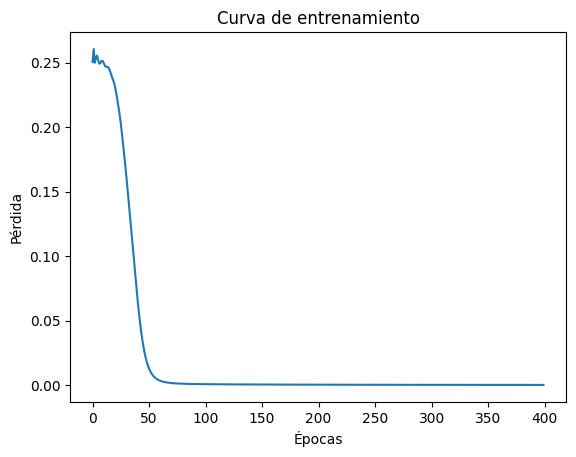

In [72]:
plt.plot(loss_list)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Curva de entrenamiento')
plt.show()